In [16]:
import os, sys
from glob import glob
from pathlib import Path
import json

import pickle
import numpy as np
import matplotlib.pyplot as plt
import cv2
from dataclasses import dataclass


@dataclass
class SeamLine :
    segment_idx_arr_list : list
    segment_pos_arr_list : list
    segment_edge_len_arr_list : list
    segment_t_arr_list : list
    segment_u_arr_list : list
    segment_v_arr_list : list
    
@dataclass
class SeamLineScene :
    garment_dir : Path
    garment_version : str = "01"
    
    view_name_list : list = None
    image_dict : dict = None
    seam_annotation_dict : dict = None
    
    def __post_init__(self) :
        self.garment_id_list = str(Path(self.garment_dir).name).split("__")[::2]
    
        self.spec_path_list = []
        for garment_id in self.garment_id_list :
            spec_path = str(Path(self.garment_dir) / f"{garment_id}__{self.garment_version}__specification.json")
            if os.path.exists(spec_path) :
                self.spec_path_list.append(spec_path)
            else :
                spec_path = str(Path(self.garment_dir) / f"{garment_id}_specification.json")
                self.spec_path_list.append(spec_path)
        
        self.stitch_dict_list = []
        for spec_path in self.spec_path_list:
            with open(spec_path, "r") as f:
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]):
                stitch_dict[idx] = stitch
            self.stitch_dict_list.append(stitch_dict)
            
        self.stitch_dict_dict = {}
        for garment_id, spec_path in zip(self.garment_id_list, self.spec_path_list) :
            with open(spec_path, "r") as f :
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]) :
                stitch_dict[idx] = stitch
            self.stitch_dict_dict[garment_id] = stitch_dict
        
        self.garment_count = len(self.spec_path_list)
    
        self.rendered_path_list = sorted(glob(os.path.join(
            self.garment_dir, "Custom*_1.png"
        )))
        self.view_name_list = list(map(
            lambda x: Path(x).stem[:-2],
            self.rendered_path_list
        ))
        self.rendered_img_dict = dict(zip(
            self.view_name_list,
            list(map(
                lambda x : plt.imread(x),  # cv2.imread(x),
                self.rendered_path_list
            ))
        ))
        
        print(self.rendered_path_list)
        print(self.view_name_list)
        
        self.image_dict = {}
        for view_name in self.view_name_list :
            self.image_dict[view_name] = plt.imread(
                str(Path(self.garment_dir) / f"{view_name}.png")
            )
            
        self.seam_annotation_dict = {}
        for view_name in self.view_name_list :
            with open(str(Path(self.garment_dir) / f"{view_name}.pkl"), "rb") as f :
                self.seam_annotation_dict[view_name] = pickle.load(f)




In [2]:
garment_dir_list = sorted(glob(os.path.join(
    "..", "SAMPLE_DATA", "GCD__GOOD", "*"
))) + sorted(glob(os.path.join(
    "..", "SAMPLE_DATA", "SEWFACTORY__GOOD", "*"
)))


['../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_0__Dynamic_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_10__Dynamic_2_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_1__Dynamic_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_2__Dramatic_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_3__Dramatic_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_4__Dramatic_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_5__Dynamic_2_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_6__FV2_05_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_7__Dynamic_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_8__FV2_07_1.png', '../SAMPLE_DATA/GCD__GOOD/rand_04ANOD2PBA__01/Custom_View_9__Dynamic_2_1.png']
['Custom_View_0__Dynamic', 'Custom_View_10__Dynamic_2', 'Custom_View_1__Dynamic', 'Custom_View_2__Dramatic', 'Custom_View_3__Dramatic', 'Custom_

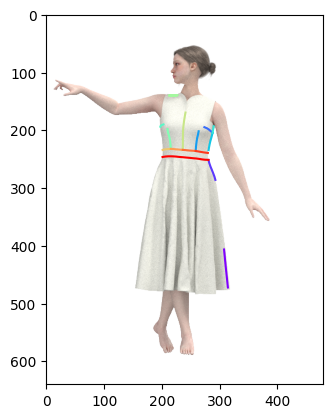

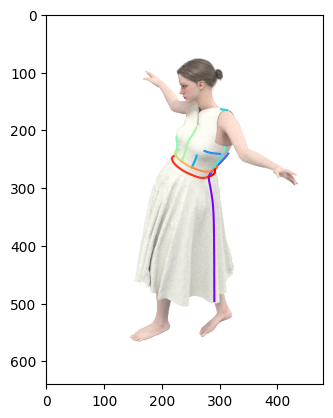

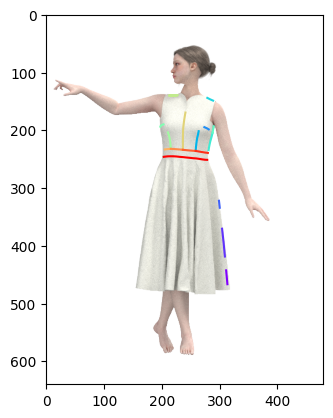

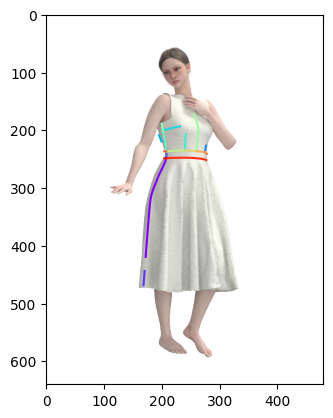

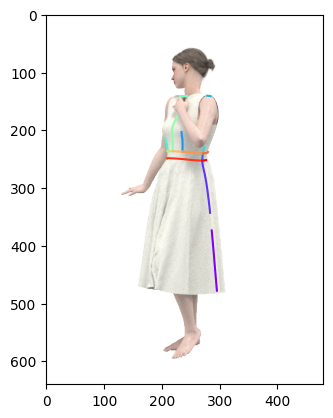

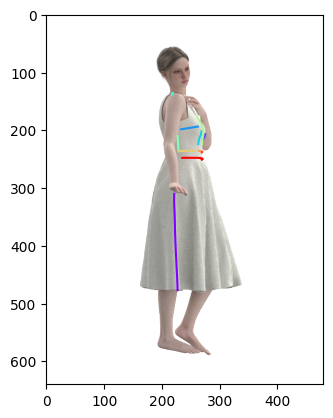

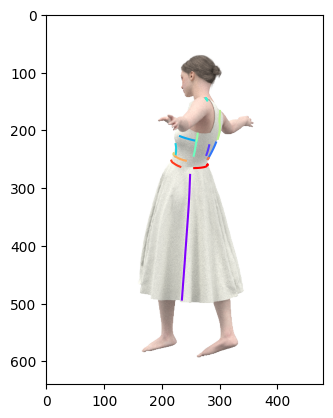

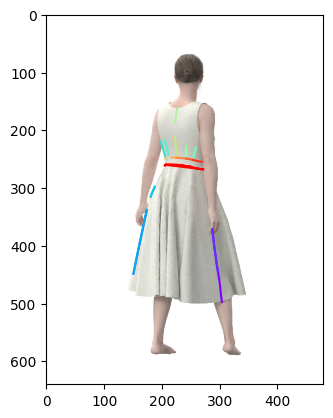

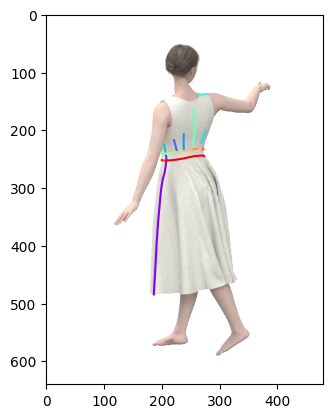

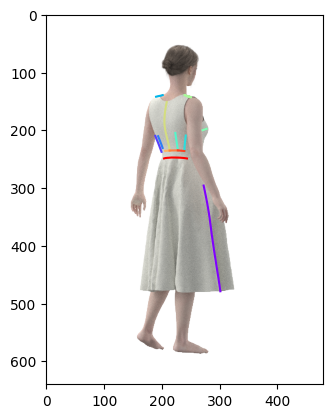

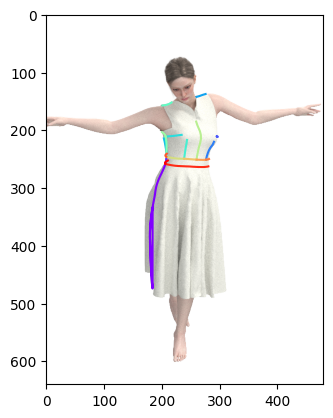

In [19]:
IDX = 0

scene = SeamLineScene(
    garment_dir=garment_dir_list[IDX]
)

for view_name in scene.view_name_list :
    
    img = scene.image_dict[view_name]
    seam_annotation = scene.seam_annotation_dict[view_name]
    
    plt.imshow(img)

    vis_seam_seg_pos_list = []
    for garment_id in seam_annotation.keys() :
        for stch_idx, sema_line in seam_annotation[garment_id].items() :
            for segment_pos_arr in sema_line['segment_pos_arr_list'] :
                vis_seam_seg_pos_list.append(segment_pos_arr)
    
    color_list = plt.cm.rainbow(np.linspace(0, 1, len(vis_seam_seg_pos_list)))
    for pos_arr, color in zip(vis_seam_seg_pos_list, color_list) :
        plt.plot(pos_arr[:, 0], pos_arr[:, 1], color=color)
    
    
    
    plt.show()

{'rand_04ANOD2PBA': {1: {'segment_idx_arr_list': [array([12511, 12512, 12513, 12514, 12515, 12516, 12517, 12518, 12519,
           12520, 12521, 12522]),
    array([12542, 12543, 12544, 12545, 12546, 12547, 12548])],
   'segment_pos_arr_list': [array([[314.31032196, 471.867369  ],
           [313.65810332, 465.89381564],
           [313.05342679, 459.91502132],
           [312.42691929, 453.9413804 ],
           [311.80363053, 447.97036352],
           [311.18286615, 441.99236467],
           [310.55762906, 436.01588627],
           [309.97275679, 430.03852817],
           [309.38500351, 424.05774581],
           [308.79197581, 418.0716576 ],
           [308.21001626, 412.07880982],
           [307.667406  , 406.08966977]]),
    array([[292.61734815, 285.61313828],
           [290.93906722, 279.69606291],
           [288.77896113, 273.95489627],
           [286.53753547, 268.26289139],
           [284.19887751, 262.62523661],
           [282.19337797, 256.88717925],
           [280.698